<a href="https://colab.research.google.com/github/hi-sy/project/blob/main/logistic_regression_model4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseline Logistic Regression Model — Mortgage Default Determinants

UK RMBS loan-level data. Continues from the cleaning script (`code.ipynb`), which ends at Figure 10. Implements Step 8 of the course's 8-step pre-processing framework (model assumptions, choice of technique).

**Design note**: RQ1 is an inference question (coefficients, odds ratios, significance), so the baseline model and both formal tests below are fit on the **full sample**, not a train/test split - a split would only reduce coefficient precision for no benefit here, since there is nothing to tune. A held-out 80/20 split is reserved for a later, separate script comparing this model's predictive performance against Random Forest/XGBoost, where held-out evaluation is the right tool. Predictive performance for THIS model (ROC-AUC, PR-AUC, threshold calibration) is instead estimated via 5-fold cross-validation on the full sample - contextual/secondary content, not the RQ itself.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix,
    precision_score, recall_score, f1_score,
)
from scipy import stats

from google.colab import drive
drive.mount("/content/drive")

DATA_FOLDER = "/content/drive/MyDrive/Dissertation/data"
RANDOM_STATE = 42


Mounted at /content/drive


In [2]:
# Okabe-Ito palette, continued from the cleaning script
PALETTE = {
    "primary": "#0072B2",
    "highlight": "#D55E00",
    "secondary": "#009E73",
    "tertiary": "#E69F00",
    "neutral": "#3A3A3A",
}
plt.rcParams.update({
    "axes.edgecolor": PALETTE["neutral"],
    "axes.labelcolor": PALETTE["neutral"],
    "xtick.color": PALETTE["neutral"],
    "ytick.color": PALETTE["neutral"],
    "text.color": PALETTE["neutral"],
    "axes.grid": True,
    "grid.color": "#D9D9D9",
    "grid.linewidth": 0.5,
    "figure.dpi": 110,
})

FIGURE_COUNTER = {"n": 10}  # continues from the cleaning script's Figure 10


def styled_figure(title, xlabel, ylabel):
    """Make a figure with consistent styling and auto-numbered title."""
    FIGURE_COUNTER["n"] += 1
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.set_title(f"Figure {FIGURE_COUNTER['n']}: {title}",
                 fontsize=11, fontweight="bold", color=PALETTE["neutral"], pad=12)
    ax.set_xlabel(xlabel, fontsize=9.5)
    ax.set_ylabel(ylabel, fontsize=9.5)
    return fig, ax


In [3]:
def hosmer_lemeshow_test(y_true, y_pred_prob, groups=10):
    """Hosmer-Lemeshow goodness-of-fit test. Groups collapse automatically
    if predicted probabilities repeat enough to break qcut into fewer
    than `groups` bins; df is based on the actual group count formed."""
    data = pd.DataFrame({"y": np.asarray(y_true), "prob": np.asarray(y_pred_prob)})
    data["decile"] = pd.qcut(data["prob"], q=groups, duplicates="drop")
    grouped = data.groupby("decile", observed=True)
    obs_events = grouped["y"].sum()
    n_per_group = grouped["y"].count()
    obs_nonevents = n_per_group - obs_events
    exp_events = grouped["prob"].sum()
    exp_nonevents = n_per_group - exp_events
    hl_stat = (
        ((obs_events - exp_events) ** 2 / exp_events)
        + ((obs_nonevents - exp_nonevents) ** 2 / exp_nonevents)
    ).sum()
    df_hl = len(grouped) - 2
    p_value = 1 - stats.chi2.cdf(hl_stat, df_hl)
    return hl_stat, df_hl, p_value


def youdens_j_threshold(y_true, y_pred_prob):
    """Threshold maximising Youden's J = TPR - FPR (Youden, 1950) - the
    same quantity as the Kolmogorov-Smirnov (KS) statistic used for
    cutoff selection in credit scoring (Hand & Henley, 1997; Hand, 2005;
    Fang & Chen, 2019)."""
    fpr, tpr, thresh = roc_curve(y_true, y_pred_prob)
    j_scores = tpr - fpr
    return thresh[np.argmax(j_scores)]


def f1_threshold(y_true, y_pred_prob):
    """Threshold maximising F1 - an alternative to Youden's J that weights
    precision directly, per Kuhn & Johnson (Applied Predictive Modeling,
    Ch. 16.4), which presents Youden's J and F1/target-driven cutoffs as
    alternative, context-dependent choices, not one 'correct' criterion."""
    prec, rec, thresh = precision_recall_curve(y_true, y_pred_prob)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    return thresh[np.argmax(f1[:-1])]


## Step 1: Load Data and Build the Predictor Set

`InterestRate_AtReference` is added here in response to the Step 2b diagnostic finding (run in an earlier pass of this analysis, documented in `decisions_log.md` Part B.5b/B.5c) - not assumed upfront. The elevated risk sits precisely at `Interest_Rate == 4.74` (default rate 1.56%, n=90,953) vs. other values in the 4.0-4.74 band (1.06%) vs. rate <= 4.0 (0.35%): a threshold at one specific reference rate, not a smooth band, so a step-function dummy matches it exactly - unlike a polynomial term (wrong shape for a localised jump) or a spline (unnecessary complexity, loses single-coefficient interpretability for a control variable). Plausible mechanism: 4.74 is likely a standard/reversion rate borrowers land on after an initial deal expires.

In [4]:
# load the cleaned data and sanity-check it against the cleaning script's
# final printout before trusting this is the current version
df = pd.read_csv(f"{DATA_FOLDER}/cleaned_dissertation_data.csv", low_memory=False)
print(f"Loaded: {len(df):,} rows, {df.shape[1]} cols, "
      f"default rate = {df['default'].mean():.2%}")
print("Compare against the cleaning script's final printout "
      "(163,348 rows, 61 cols, 1.05%) before proceeding.")

# predictor set, locked in the preprocessing decisions log
continuous_predictors = ["Original_LTV", "Interest_Rate", "Loan_Term", "Income_log"]
proptype_dummies = ["PropType_Flat", "PropType_Bungalow", "PropType_Terraced"]
purpose_dummies = [
    "Purpose_Remortgage", "Purpose_DebtConsolidation",
    "Purpose_Renovation", "Purpose_RemortgageEquityRelease", "Purpose_Other",
]
incverif_dummies = ["IncVerif_Other"]

df["InterestRate_AtReference"] = (df["Interest_Rate"] == 4.74).astype(float)
structural_predictors = ["InterestRate_AtReference"]

predictors = (
    continuous_predictors + structural_predictors
    + proptype_dummies + purpose_dummies + incverif_dummies
)

X = df[predictors].astype(float)
y = df["default"].astype(int)


Loaded: 163,348 rows, 61 cols, default rate = 1.05%
Compare against the cleaning script's final printout (163,348 rows, 61 cols, 1.05%) before proceeding.


## Step 2a: Multicollinearity (VIF)

On the continuous predictors plus the new step-function indicator (derived from `Interest_Rate`, checked for collinearity with it).

In [5]:
vif_check_cols = continuous_predictors + structural_predictors
X_vif = sm.add_constant(X[vif_check_cols])
vif_data = pd.DataFrame({
    "predictor": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
print(vif_data[vif_data["predictor"] != "const"].to_string(index=False))
print("VIF > 5-10 would indicate problematic multicollinearity.")


               predictor      VIF
            Original_LTV 1.284436
           Interest_Rate 2.665650
               Loan_Term 1.193077
              Income_log 1.082345
InterestRate_AtReference 2.662191
VIF > 5-10 would indicate problematic multicollinearity.


### Correlation Heatmap

Companion to the VIF table above - same predictor set, shows pairwise structure VIF summarizes as a single number per variable.

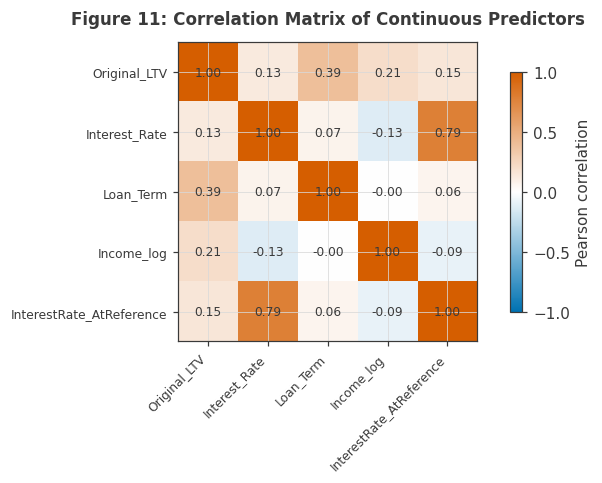

In [6]:
from matplotlib.colors import LinearSegmentedColormap
diverging_cmap = LinearSegmentedColormap.from_list(
    "okabe_diverging", [PALETTE["primary"], "#FFFFFF", PALETTE["highlight"]]
)
corr_matrix = X[vif_check_cols].corr()
fig, ax = styled_figure(
    "Correlation Matrix of Continuous Predictors", "", ""
)
im = ax.imshow(corr_matrix, cmap=diverging_cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(vif_check_cols)))
ax.set_yticks(range(len(vif_check_cols)))
ax.set_xticklabels(vif_check_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(vif_check_cols, fontsize=8)
for i in range(len(vif_check_cols)):
    for j in range(len(vif_check_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center",
                 fontsize=8, color=PALETTE["neutral"])
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation")
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig{FIGURE_COUNTER['n']}_correlation_heatmap.png",
            bbox_inches="tight")
plt.show()


## Step 2b: Linearity of the Logit

Empirical logit by decile, not Box-Tidwell, since `Interest_Rate` and `Income_log` both contain zero values and Box-Tidwell requires strictly positive predictors.

`Interest_Rate` is binned with custom breakpoints, not `qcut`: `qcut` collapses to only 5 wildly unequal bins here (one holding 65% of the sample) because of extreme value clustering at reference rates (4.74 alone is ~56% of the sample). `Original_LTV`, `Loan_Term`, and `Income_log` all bin cleanly with `qcut` (checked - worst imbalance ~3.4x, nothing like `Interest_Rate`'s ~14x) and are unaffected.

Original_LTV: 10 bins, n range 16,034-16,590


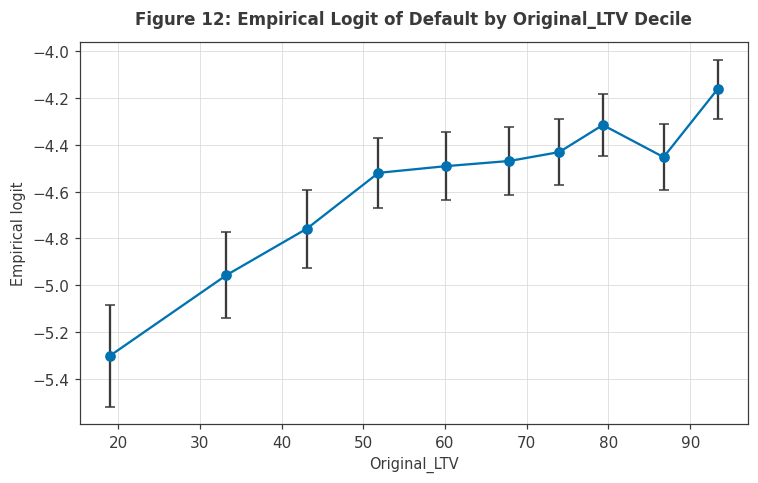

Interest_Rate: 9 bins, n range 3,077-94,363


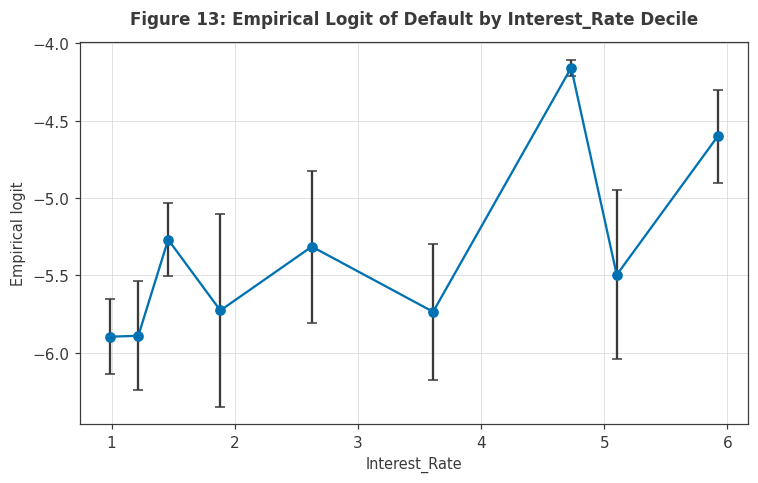

Loan_Term: 10 bins, n range 6,716-22,879


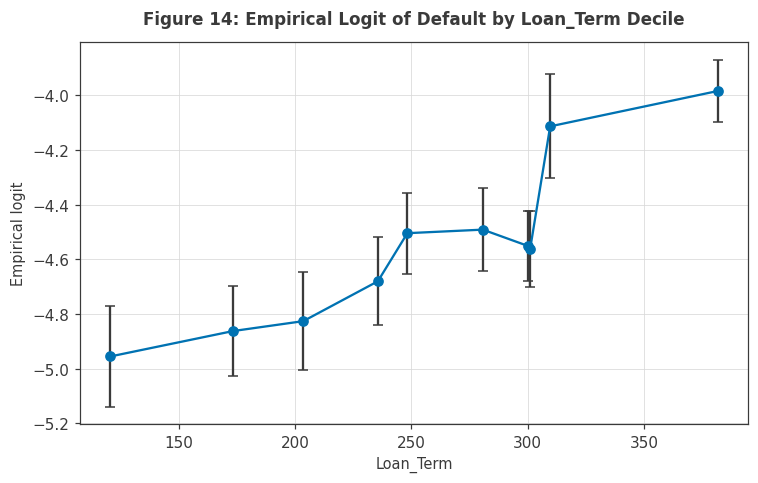

Income_log: 10 bins, n range 16,090-16,585


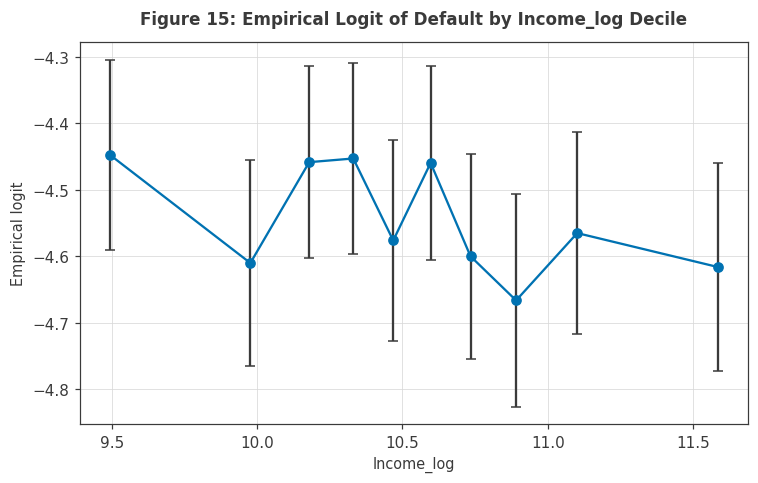

Roughly linear/monotonic patterns support the linearity assumption; error bars (95% CI on the empirical logit) show whether apparent wiggle exceeds sampling noise - check the plots visually. Interest_Rate's genuine jump at the 4.0-4.74 band (confirmed real, not noise) is addressed via InterestRate_AtReference above, not by leaving Interest_Rate as a strictly linear term.


In [7]:
for col in continuous_predictors:
    tmp = pd.DataFrame({col: X[col], "y": y})
    if col == "Interest_Rate":
        breaks = [-0.01, 1.0, 1.25, 1.5, 2.0, 3.0, 4.0, 4.74, 5.5, 8.0]
        tmp["bin"] = pd.cut(tmp[col], bins=breaks)
    else:
        tmp["bin"] = pd.qcut(tmp[col], q=10, duplicates="drop")
    grp = tmp.groupby("bin", observed=True).agg(
        mean_x=(col, "mean"), mean_y=("y", "mean"), n=("y", "count")
    )
    p = grp["mean_y"].clip(0.0005, 0.9995)
    grp["empirical_logit"] = np.log(p / (1 - p))
    grp["approx_se"] = np.sqrt(1 / (grp["n"] * p) + 1 / (grp["n"] * (1 - p)))
    print(f"{col}: {len(grp)} bins, n range {grp['n'].min():,}-{grp['n'].max():,}")
    fig, ax = styled_figure(
        f"Empirical Logit of Default by {col} Decile", col, "Empirical logit"
    )
    ax.errorbar(grp["mean_x"], grp["empirical_logit"], yerr=1.96 * grp["approx_se"],
                marker="o", color=PALETTE["primary"], ecolor=PALETTE["neutral"],
                capsize=3)
    plt.tight_layout()
    plt.savefig(f"{DATA_FOLDER}/fig{FIGURE_COUNTER['n']}_logit_{col}.png",
                bbox_inches="tight")
    plt.show()
print("Roughly linear/monotonic patterns support the linearity assumption; "
      "error bars (95% CI on the empirical logit) show whether apparent "
      "wiggle exceeds sampling noise - check the plots visually. "
      "Interest_Rate's genuine jump at the 4.0-4.74 band (confirmed real, "
      "not noise) is addressed via InterestRate_AtReference above, not by "
      "leaving Interest_Rate as a strictly linear term.")


### Interest_Rate: Naive vs. Corrected Fit

Overlay of the empirical logit points, a naive linear-only fit, and the corrected linear+step-function fit - shows in one figure why the `InterestRate_AtReference` term was added. Two small univariate/near-univariate models are fit here purely for this illustrative overlay, separate from the main baseline model.

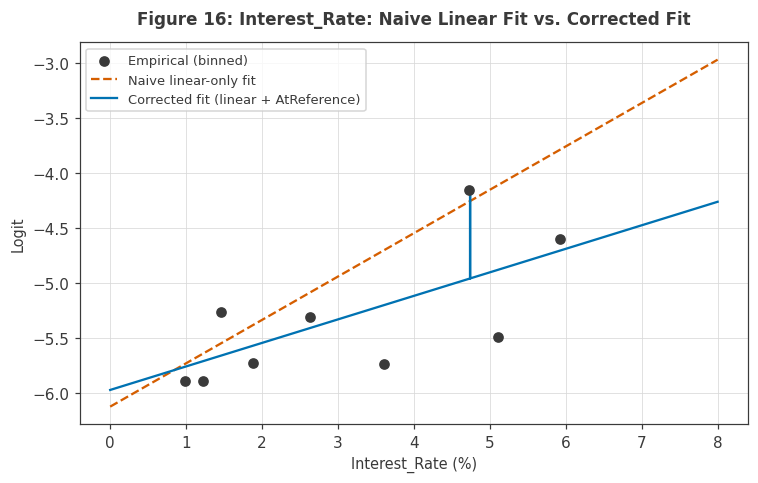

In [8]:
tmp_ir = pd.DataFrame({"Interest_Rate": X["Interest_Rate"], "y": y})
breaks = [-0.01, 1.0, 1.25, 1.5, 2.0, 3.0, 4.0, 4.74, 5.5, 8.0]
tmp_ir["bin"] = pd.cut(tmp_ir["Interest_Rate"], bins=breaks)
grp_ir = tmp_ir.groupby("bin", observed=True).agg(
    mean_x=("Interest_Rate", "mean"), mean_y=("y", "mean"), n=("y", "count")
)
p_ir = grp_ir["mean_y"].clip(0.0005, 0.9995)
grp_ir["empirical_logit"] = np.log(p_ir / (1 - p_ir))

naive_model = sm.Logit(y, sm.add_constant(X[["Interest_Rate"]])).fit(disp=0)
corrected_model = sm.Logit(
    y, sm.add_constant(X[["Interest_Rate", "InterestRate_AtReference"]])
).fit(disp=0)

grid = np.sort(np.unique(np.concatenate([
    np.linspace(0, 8, 200), [4.739, 4.74, 4.741]
])))
naive_logit = naive_model.params["const"] + naive_model.params["Interest_Rate"] * grid
grid_at_ref = (grid == 4.74).astype(float)
corrected_logit = (
    corrected_model.params["const"]
    + corrected_model.params["Interest_Rate"] * grid
    + corrected_model.params["InterestRate_AtReference"] * grid_at_ref
)

fig, ax = styled_figure(
    "Interest_Rate: Naive Linear Fit vs. Corrected Fit", "Interest_Rate (%)", "Logit"
)
ax.scatter(grp_ir["mean_x"], grp_ir["empirical_logit"], color=PALETTE["neutral"],
           zorder=3, label="Empirical (binned)")
ax.plot(grid, naive_logit, color=PALETTE["highlight"], linestyle="--",
        label="Naive linear-only fit")
ax.plot(grid, corrected_logit, color=PALETTE["primary"],
        label="Corrected fit (linear + AtReference)")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig{FIGURE_COUNTER['n']}_interest_rate_fit_comparison.png",
            bbox_inches="tight")
plt.show()


## Step 2c: Separation Check

In [9]:
for col in proptype_dummies + purpose_dummies + incverif_dummies:
    sub = y[X[col] == 1]
    print(f"{col}: n={len(sub):,}, events={sub.sum():,}, rate={sub.mean():.4f}")


PropType_Flat: n=18,676, events=173, rate=0.0093
PropType_Bungalow: n=11,249, events=144, rate=0.0128
PropType_Terraced: n=49,467, events=601, rate=0.0121
Purpose_Remortgage: n=52,165, events=523, rate=0.0100
Purpose_DebtConsolidation: n=23,559, events=423, rate=0.0180
Purpose_Renovation: n=7,248, events=94, rate=0.0130
Purpose_RemortgageEquityRelease: n=9,387, events=75, rate=0.0080
Purpose_Other: n=1,611, events=17, rate=0.0106
IncVerif_Other: n=58,727, events=623, rate=0.0106


### Raw Default Rate by Property Type (Unadjusted)

The "before" picture to compare against the model-adjusted odds ratios (Figure 18, later). If the raw and adjusted pictures broadly agree, that is reassuring robustness; if they differ, that is itself a finding worth discussing for RQ1. `House` is included here (it is the model's reference category, not absent from the data).

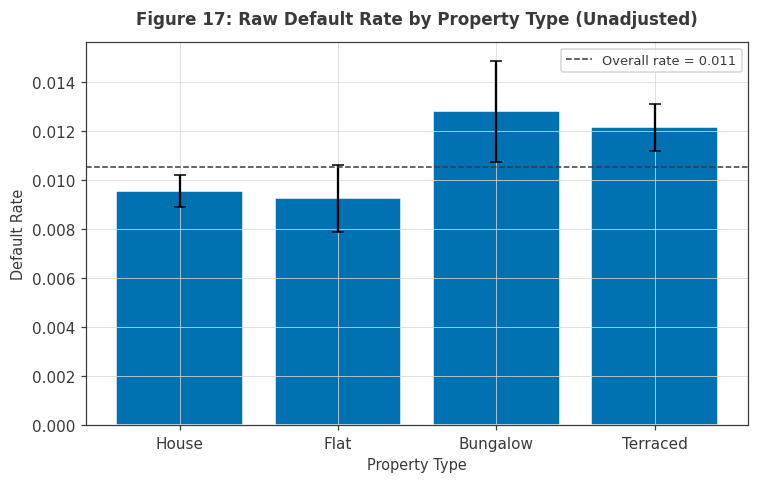

Compare against the model-adjusted odds ratios below (Property_Type coefficients) - agreement or divergence between the raw and adjusted pictures is itself worth discussing for RQ1.


In [10]:
proptype_raw = pd.DataFrame({
    "Property_Type": df["Property_Type"].map(
        {1.0: "House", 2.0: "Flat", 3.0: "Bungalow", 4.0: "Terraced"}
    ),
    "default": y,
})
raw_rates = proptype_raw.groupby("Property_Type")["default"].agg(["mean", "count", "sum"])
raw_rates["se"] = np.sqrt(raw_rates["mean"] * (1 - raw_rates["mean"]) / raw_rates["count"])
raw_rates = raw_rates.reindex(["House", "Flat", "Bungalow", "Terraced"])

fig, ax = styled_figure(
    "Raw Default Rate by Property Type (Unadjusted)", "Property Type", "Default Rate"
)
ax.bar(raw_rates.index, raw_rates["mean"], yerr=1.96 * raw_rates["se"],
       color=PALETTE["primary"], capsize=4, edgecolor="white")
ax.axhline(y.mean(), color=PALETTE["neutral"], linestyle="--", linewidth=1,
           label=f"Overall rate = {y.mean():.3f}")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig{FIGURE_COUNTER['n']}_raw_default_by_proptype.png",
            bbox_inches="tight")
plt.show()
print("Compare against the model-adjusted odds ratios below (Property_Type "
      "coefficients) - agreement or divergence between the raw and "
      "adjusted pictures is itself worth discussing for RQ1.")


## Step 3: Fit the Baseline Model

Fit on the **full sample** - maximises coefficient precision for the inferential RQ, no held-out data needed since there is nothing to tune.

In [11]:
X_const = sm.add_constant(X)
baseline_model = sm.Logit(y, X_const).fit(disp=0, maxiter=100)
print(baseline_model.summary())

odds_ratios = pd.DataFrame({
    "coefficient": baseline_model.params,
    "odds_ratio": np.exp(baseline_model.params),
    "ci_lower": np.exp(baseline_model.conf_int()[0]),
    "ci_upper": np.exp(baseline_model.conf_int()[1]),
    "p_value": baseline_model.pvalues,
})
print("\nOdds ratios with 95% CI:")
print(odds_ratios.round(4))
print(f"\nMcFadden pseudo-R2: {baseline_model.prsquared:.4f}")


                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:               163348
Model:                          Logit   Df Residuals:                   163333
Method:                           MLE   Df Model:                           14
Date:                Mon, 17 Aug 2026   Pseudo R-squ.:                 0.04784
Time:                        21:24:18   Log-Likelihood:                -9090.8
converged:                       True   LL-Null:                       -9547.6
Covariance Type:            nonrobust   LLR p-value:                5.647e-186
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                              -7.2805      0.517    -14.071      0.000      -8.295      -6.266
Original_LTV                        0.0098      0.001      7.138    

### Goodness of Fit: Hosmer-Lemeshow and Calibration

The calibration plot provides direct empirical evidence of fit alongside the p-value, since Hosmer-Lemeshow is known to be highly sensitive at this sample size (Paul, Pennell & Lemeshow, 2013) - even practically trivial calibration deviations can become statistically significant.

Hosmer-Lemeshow test: chi2=13.163, df=8, p=0.1064
p >= 0.05: fails to reject the null of good fit - no evidence of miscalibration detected, even accounting for this test's known high sensitivity at large n (Paul, Pennell & Lemeshow, 2013, Statistics in Medicine 32, 67-80). The calibration plot below provides direct corroborating evidence.

Calibration by decile (predicted vs. observed default rate):
                      mean_pred  mean_obs      n
decile                                          
(-0.000273, 0.00247]     0.0019    0.0020  16335
(0.00247, 0.00329]       0.0029    0.0028  16335
(0.00329, 0.00434]       0.0038    0.0047  16335
(0.00434, 0.00634]       0.0052    0.0047  16334
(0.00634, 0.00904]       0.0077    0.0072  16335
(0.00904, 0.0116]        0.0103    0.0101  16335
(0.0116, 0.0139]         0.0127    0.0127  16334
(0.0139, 0.0165]         0.0152    0.0171  16335
(0.0165, 0.021]          0.0185    0.0164  16335
(0.021, 0.0787]          0.0271    0.0277  16335


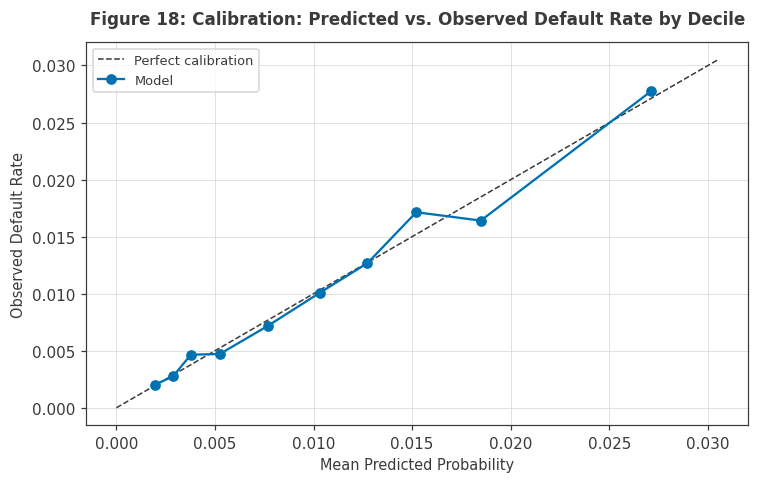

In [12]:
hl_stat, hl_df, hl_p = hosmer_lemeshow_test(y, baseline_model.predict(X_const))
print(f"Hosmer-Lemeshow test: chi2={hl_stat:.3f}, df={hl_df}, p={hl_p:.4f}")
if hl_p < 0.05:
    print("p < 0.05 rejects the null of good fit. At n=163,348 this test is "
          "known to be highly sensitive - even practically trivial "
          "calibration deviations become statistically significant (Paul, "
          "Pennell & Lemeshow, 2013, Statistics in Medicine 32, 67-80). The "
          "calibration plot below shows whether the deviation is "
          "practically meaningful, not just statistically detectable.")
else:
    print("p >= 0.05: fails to reject the null of good fit - no evidence "
          "of miscalibration detected, even accounting for this test's "
          "known high sensitivity at large n (Paul, Pennell & Lemeshow, "
          "2013, Statistics in Medicine 32, 67-80). The calibration plot "
          "below provides direct corroborating evidence.")

# calibration plot: predicted vs. observed default rate by decile
calib_pred = baseline_model.predict(X_const)
calib_df = pd.DataFrame({"pred": calib_pred, "obs": y})
calib_df["decile"] = pd.qcut(calib_df["pred"], q=10, duplicates="drop")
calib = calib_df.groupby("decile", observed=True).agg(
    mean_pred=("pred", "mean"), mean_obs=("obs", "mean"), n=("obs", "count")
)
print("\nCalibration by decile (predicted vs. observed default rate):")
print(calib.round(4))

fig, ax = styled_figure(
    "Calibration: Predicted vs. Observed Default Rate by Decile",
    "Mean Predicted Probability", "Observed Default Rate"
)
max_val = max(calib["mean_pred"].max(), calib["mean_obs"].max()) * 1.1
ax.plot([0, max_val], [0, max_val], color=PALETTE["neutral"], linestyle="--",
        linewidth=1, label="Perfect calibration")
ax.plot(calib["mean_pred"], calib["mean_obs"], marker="o", color=PALETTE["primary"],
        label="Model")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig{FIGURE_COUNTER['n']}_calibration.png", bbox_inches="tight")
plt.show()


## Step 4: RQ1 Formal Test

Likelihood-ratio test for `Property_Type`, full model vs. `Property_Type` dummies removed, full sample.

In [13]:
restricted_predictors = [p for p in X.columns if p not in proptype_dummies]
X_restricted = sm.add_constant(X[restricted_predictors])
restricted_model = sm.Logit(y, X_restricted).fit(disp=0, maxiter=100)

lr_stat = -2 * (restricted_model.llf - baseline_model.llf)
lr_df = len(proptype_dummies)
lr_p = 1 - stats.chi2.cdf(lr_stat, lr_df)
print(f"RQ1 likelihood-ratio test (Property_Type as a set): "
      f"LR={lr_stat:.3f}, df={lr_df}, p={lr_p:.5f}")


RQ1 likelihood-ratio test (Property_Type as a set): LR=34.680, df=3, p=0.00000


## Step 5: Pool-Heterogeneity Robustness Check

HOLMES vs. LANGTON only - Paragon (153 surviving loans, 0 defaults) has complete separation and can't support a finite coefficient; LEGO3/Moorgate/SILVRSTONE are too small for any formal test. Both reported descriptively below.

In [14]:
mask_hl = df["Pool_Identifier"].isin(["HOLMES", "LANGTON"])
X_hl = X.loc[mask_hl].copy()
y_hl = y.loc[mask_hl]
X_hl["LANGTON"] = (df.loc[mask_hl, "Pool_Identifier"] == "LANGTON").astype(int)

model_with_pool = sm.Logit(y_hl, sm.add_constant(X_hl)).fit(disp=0, maxiter=100)
model_no_pool = sm.Logit(y_hl, sm.add_constant(X_hl.drop(columns=["LANGTON"]))).fit(
    disp=0, maxiter=100
)

pool_lr_stat = -2 * (model_no_pool.llf - model_with_pool.llf)
pool_lr_p = 1 - stats.chi2.cdf(pool_lr_stat, 1)
print(f"Pool heterogeneity LR test (HOLMES vs LANGTON): "
      f"LR={pool_lr_stat:.3f}, df=1, p={pool_lr_p:.5f}")

print("\nProperty_Type coefficient stability (without vs with LANGTON control):")
for col in proptype_dummies:
    b_without = model_no_pool.params[col]
    b_with = model_with_pool.params[col]
    pct_change = abs(b_with - b_without) / abs(b_without) * 100 if b_without != 0 else float("nan")
    print(f"{col}: without pool={b_without:.4f}, with pool={b_with:.4f}, "
          f"change={pct_change:.1f}%")
print("Change > ~10% (Mickey & Greenland, 1989) would indicate Pool is a "
      "real confounder needing inclusion in the baseline spec; change "
      "below that supports reporting the LR test as a robustness finding only.")

tiny_pool_names = ["Paragon Mortgages (No.19) PLC", "LEGO3", "Moorgate 2014-1", "SILVRSTONE"]
print("\nExcluded pools (too small/separated for any formal test):")
print(df[df["Pool_Identifier"].isin(tiny_pool_names)]
      .groupby("Pool_Identifier")["default"].agg(["sum", "count", "mean"]))
print("Firth's penalized regression (Firth, 1993) was considered as the "
      "standard fix for Paragon's separation and declined as "
      "disproportionate to a robustness check on <0.1% of the sample.")


Pool heterogeneity LR test (HOLMES vs LANGTON): LR=330.043, df=1, p=0.00000

Property_Type coefficient stability (without vs with LANGTON control):
PropType_Flat: without pool=-0.2573, with pool=-0.2438, change=5.2%
PropType_Bungalow: without pool=0.4419, with pool=0.4229, change=4.3%
PropType_Terraced: without pool=0.0069, with pool=-0.0073, change=205.4%
Change > ~10% (Mickey & Greenland, 1989) would indicate Pool is a real confounder needing inclusion in the baseline spec; change below that supports reporting the LR test as a robustness finding only.

Excluded pools (too small/separated for any formal test):
                               sum  count      mean
Pool_Identifier                                    
LEGO3                            3      3  1.000000
Moorgate 2014-1                 11     14  0.785714
Paragon Mortgages (No.19) PLC    0    153  0.000000
SILVRSTONE                       7      7  1.000000
Firth's penalized regression (Firth, 1993) was considered as the stan

## Step 6: Predictive Performance (5-Fold CV)

Secondary/contextual content for the discussion - RQ1 does not depend on this section.

Each fold's ROC-AUC/PR-AUC is computed on that fold's held-out predictions ONLY, then averaged across folds - never pooled into one merged vector before computing AUC, which produces a biased estimate under class imbalance (Forman & Scholz, 2010).

The Youden's J / KS threshold is selected via a **nested** inner 5-fold CV within each outer fold's training portion, then applied to that same outer fold's held-out predictions - so the threshold is never chosen using the same data it is then evaluated on. This single cell keeps the whole nested-CV loop together, since it's one continuous loop with state carrying across iterations.

In [15]:
outer_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_roc_auc, fold_pr_auc = [], []
fold_precision, fold_recall, fold_f1, fold_thresholds = [], [], [], []
# aggregate confusion matrices (summed across folds' out-of-fold
# predictions at each fold's own threshold) - valid to sum since these
# are discrete counts at an already-fixed cutoff, not a rank-based
# metric like AUC (Forman & Scholz's pooling-bias concern doesn't apply
# to summing confusion matrix counts).
agg_cm_youden = np.zeros((2, 2), dtype=int)
agg_cm_f1opt = np.zeros((2, 2), dtype=int)
fold_f1_precision, fold_f1_recall, fold_f1_f1, fold_f1_thresholds = [], [], [], []
mean_fpr_grid = np.linspace(0, 1, 100)
interp_tprs = []
all_prec_curves, all_rec_curves = [], []

for fold, (outer_tr_idx, outer_te_idx) in enumerate(outer_skf.split(X, y), 1):
    X_outer_tr, X_outer_te = X.iloc[outer_tr_idx], X.iloc[outer_te_idx]
    y_outer_tr, y_outer_te = y.iloc[outer_tr_idx], y.iloc[outer_te_idx]

    outer_model = sm.Logit(y_outer_tr, sm.add_constant(X_outer_tr)).fit(disp=0, maxiter=100)
    outer_pred = outer_model.predict(sm.add_constant(X_outer_te, has_constant="add"))

    roc_auc = roc_auc_score(y_outer_te, outer_pred)
    pr_auc = average_precision_score(y_outer_te, outer_pred)
    fold_roc_auc.append(roc_auc)
    fold_pr_auc.append(pr_auc)

    fpr, tpr, _ = roc_curve(y_outer_te, outer_pred)
    interp_tpr = np.interp(mean_fpr_grid, fpr, tpr)
    interp_tpr[0] = 0.0
    interp_tprs.append(interp_tpr)

    prec_c, rec_c, _ = precision_recall_curve(y_outer_te, outer_pred)
    all_prec_curves.append(prec_c)
    all_rec_curves.append(rec_c)

    # nested inner CV, within this outer fold's training portion only,
    # to select the threshold - never touches y_outer_te/X_outer_te.
    # Both Youden's J and F1-maximizing thresholds are computed from the
    # same inner predictions (no extra model fits) to empirically test
    # whether switching the threshold CRITERION resolves the low absolute
    # precision at this ~1% event rate, rather than assuming it would -
    # Kuhn & Johnson (Ch. 16.4) present both as valid, context-dependent
    # alternatives, and note that changing the cutoff moves samples along
    # rows of the confusion matrix, not off the diagonal - it cannot
    # create separation the model doesn't already have.
    inner_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    inner_thresholds, inner_f1_thresholds = [], []
    for inner_tr_idx, inner_val_idx in inner_skf.split(X_outer_tr, y_outer_tr):
        X_inner_tr = X_outer_tr.iloc[inner_tr_idx]
        y_inner_tr = y_outer_tr.iloc[inner_tr_idx]
        X_inner_val = X_outer_tr.iloc[inner_val_idx]
        y_inner_val = y_outer_tr.iloc[inner_val_idx]
        inner_model = sm.Logit(y_inner_tr, sm.add_constant(X_inner_tr)).fit(disp=0, maxiter=100)
        inner_pred = inner_model.predict(sm.add_constant(X_inner_val, has_constant="add"))
        inner_thresholds.append(youdens_j_threshold(y_inner_val, inner_pred))
        inner_f1_thresholds.append(f1_threshold(y_inner_val, inner_pred))

    fold_threshold = float(np.mean(inner_thresholds))
    fold_thresholds.append(fold_threshold)
    fold_f1_threshold = float(np.mean(inner_f1_thresholds))
    fold_f1_thresholds.append(fold_f1_threshold)

    outer_preds_at_threshold = (outer_pred >= fold_threshold).astype(int)
    fold_precision.append(precision_score(y_outer_te, outer_preds_at_threshold, zero_division=0))
    fold_recall.append(recall_score(y_outer_te, outer_preds_at_threshold, zero_division=0))
    fold_f1.append(f1_score(y_outer_te, outer_preds_at_threshold, zero_division=0))
    agg_cm_youden += confusion_matrix(y_outer_te, outer_preds_at_threshold, labels=[0, 1])

    outer_preds_at_f1thresh = (outer_pred >= fold_f1_threshold).astype(int)
    fold_f1_precision.append(precision_score(y_outer_te, outer_preds_at_f1thresh, zero_division=0))
    fold_f1_recall.append(recall_score(y_outer_te, outer_preds_at_f1thresh, zero_division=0))
    fold_f1_f1.append(f1_score(y_outer_te, outer_preds_at_f1thresh, zero_division=0))
    agg_cm_f1opt += confusion_matrix(y_outer_te, outer_preds_at_f1thresh, labels=[0, 1])

    print(f"Fold {fold}: ROC-AUC={roc_auc:.4f}, PR-AUC={pr_auc:.4f}, "
          f"Youden thresh={fold_threshold:.4f} (P={fold_precision[-1]:.4f}, "
          f"R={fold_recall[-1]:.4f}, F1={fold_f1[-1]:.4f}) | "
          f"F1-opt thresh={fold_f1_threshold:.4f} (P={fold_f1_precision[-1]:.4f}, "
          f"R={fold_f1_recall[-1]:.4f}, F1={fold_f1_f1[-1]:.4f})")

print(f"\nROC-AUC: {np.mean(fold_roc_auc):.4f} +/- {np.std(fold_roc_auc):.4f} "
      f"(mean +/- SD across 5 folds)")
print(f"PR-AUC: {np.mean(fold_pr_auc):.4f} +/- {np.std(fold_pr_auc):.4f} "
      f"(base rate = {y.mean():.4f} for reference - Saito & Rehmsmeier, 2015, "
      f"PR-AUC is more informative than ROC-AUC under severe imbalance)")

print(f"\nYouden's J / KS threshold (mean={np.mean(fold_thresholds):.4f}): "
      f"precision={np.mean(fold_precision):.4f}+/-{np.std(fold_precision):.4f}, "
      f"recall={np.mean(fold_recall):.4f}+/-{np.std(fold_recall):.4f}")
print(f"F1-maximizing threshold (mean={np.mean(fold_f1_thresholds):.4f}): "
      f"precision={np.mean(fold_f1_precision):.4f}+/-{np.std(fold_f1_precision):.4f}, "
      f"recall={np.mean(fold_f1_recall):.4f}+/-{np.std(fold_f1_recall):.4f}")

# aggregate confusion matrices (summed across all 5 folds' out-of-fold
# predictions, full sample n=163,348) - the raw counts behind the
# precision/recall figures above
cm_youden_df = pd.DataFrame(
    agg_cm_youden, index=["Actual: No Default", "Actual: Default"],
    columns=["Predicted: No Default", "Predicted: Default"]
)
cm_f1opt_df = pd.DataFrame(
    agg_cm_f1opt, index=["Actual: No Default", "Actual: Default"],
    columns=["Predicted: No Default", "Predicted: Default"]
)
print(f"\nAggregate confusion matrix, Youden's J threshold "
      f"(summed across 5 CV folds, n={len(y):,}):")
print(cm_youden_df)
print(f"\nAggregate confusion matrix, F1-maximizing threshold "
      f"(summed across 5 CV folds, n={len(y):,}):")
print(cm_f1opt_df)

print("Switching criteria does not resolve low absolute precision at this "
      "event rate - it trades recall for a modest precision gain along the "
      "same PR curve (Bayes' theorem: PPV is bounded by prevalence "
      "regardless of which threshold-selection rule is used). No cutoff "
      "choice creates separation the model's ROC-AUC/PR-AUC don't already "
      "show.")
print(f"At the CV-selected threshold (mean = {np.mean(fold_thresholds):.4f}, "
      f"range {min(fold_thresholds):.4f}-{max(fold_thresholds):.4f}):")
print(f"Precision: {np.mean(fold_precision):.4f} +/- {np.std(fold_precision):.4f}")
print(f"Recall: {np.mean(fold_recall):.4f} +/- {np.std(fold_recall):.4f}")
print(f"F1: {np.mean(fold_f1):.4f} +/- {np.std(fold_f1):.4f}")

# for reference only - what the naive 0.5 threshold would have done,
# illustrating why a naive cutoff fails at this event rate. Uses the
# Step 3 full-sample model's in-sample predictions purely for this
# illustrative point, not as a performance claim.
naive_preds = (baseline_model.predict(X_const) >= 0.5).astype(int)
print(f"\nFor reference - naive 0.5 threshold (illustrative only): "
      f"{naive_preds.sum():,} predicted positives out of {len(y):,} rows "
      f"({y.sum():,} actual events)")

# Documented, not implemented: at ~1% event rate, King & Zeng (2001)
# rare-events bias corrections exist for logistic regression finite-
# sample bias. Considered and deferred as a limitation given the added
# complexity relative to benefit at this event rate (see
# decisions_log.md, Part B).


Fold 1: ROC-AUC=0.6839, PR-AUC=0.0251, Youden thresh=0.0112 (P=0.0168, R=0.6599, F1=0.0328) | F1-opt thresh=0.0260 (P=0.0335, R=0.1424, F1=0.0542)
Fold 2: ROC-AUC=0.7250, PR-AUC=0.0278, Youden thresh=0.0111 (P=0.0190, R=0.7820, F1=0.0371) | F1-opt thresh=0.0253 (P=0.0373, R=0.1512, F1=0.0598)
Fold 3: ROC-AUC=0.6828, PR-AUC=0.0198, Youden thresh=0.0102 (P=0.0172, R=0.7362, F1=0.0335) | F1-opt thresh=0.0290 (P=0.0275, R=0.0783, F1=0.0407)
Fold 4: ROC-AUC=0.7010, PR-AUC=0.0224, Youden thresh=0.0106 (P=0.0181, R=0.7413, F1=0.0354) | F1-opt thresh=0.0311 (P=0.0291, R=0.0581, F1=0.0388)
Fold 5: ROC-AUC=0.7069, PR-AUC=0.0278, Youden thresh=0.0114 (P=0.0182, R=0.7035, F1=0.0355) | F1-opt thresh=0.0291 (P=0.0315, R=0.0814, F1=0.0455)

ROC-AUC: 0.6999 +/- 0.0157 (mean +/- SD across 5 folds)
PR-AUC: 0.0246 +/- 0.0031 (base rate = 0.0105 for reference - Saito & Rehmsmeier, 2015, PR-AUC is more informative than ROC-AUC under severe imbalance)

Youden's J / KS threshold (mean=0.0109): precision=0.01

## Results Figures

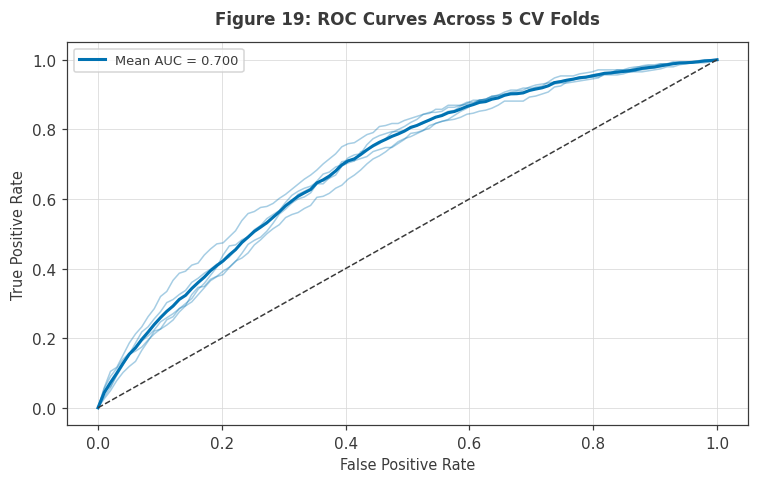

In [16]:
# ROC curves across the 5 CV folds, with mean
mean_tpr = np.mean(interp_tprs, axis=0)
mean_tpr[-1] = 1.0
fig, ax = styled_figure("ROC Curves Across 5 CV Folds", "False Positive Rate", "True Positive Rate")
for tpr_i in interp_tprs:
    ax.plot(mean_fpr_grid, tpr_i, color=PALETTE["primary"], alpha=0.35, linewidth=1)
ax.plot(mean_fpr_grid, mean_tpr, color=PALETTE["primary"],
        label=f"Mean AUC = {np.mean(fold_roc_auc):.3f}", linewidth=2)
ax.plot([0, 1], [0, 1], color=PALETTE["neutral"], linestyle="--", linewidth=1)
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig{FIGURE_COUNTER['n']}_roc_curves_cv.png", bbox_inches="tight")
plt.show()


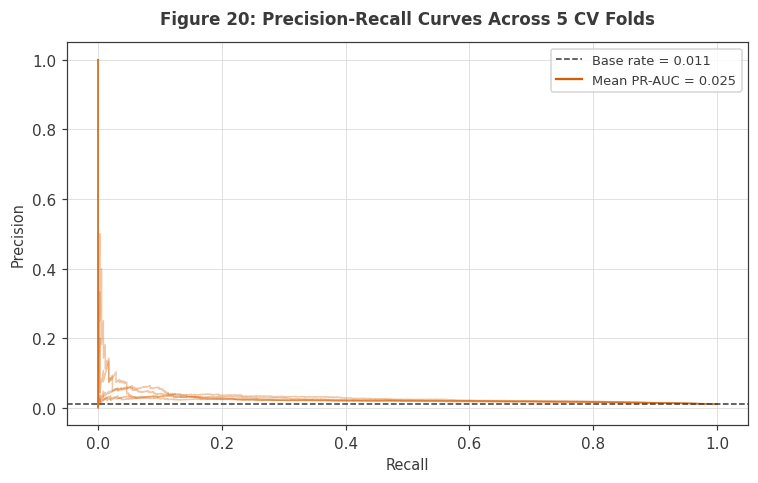

In [17]:
# Precision-Recall curves across the 5 CV folds
fig, ax = styled_figure("Precision-Recall Curves Across 5 CV Folds", "Recall", "Precision")
for prec_c, rec_c in zip(all_prec_curves, all_rec_curves):
    ax.plot(rec_c, prec_c, color=PALETTE["highlight"], alpha=0.35, linewidth=1)
ax.axhline(y.mean(), color=PALETTE["neutral"], linestyle="--", linewidth=1,
           label=f"Base rate = {y.mean():.3f}")
ax.plot([], [], color=PALETTE["highlight"], label=f"Mean PR-AUC = {np.mean(fold_pr_auc):.3f}")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig{FIGURE_COUNTER['n']}_pr_curves_cv.png", bbox_inches="tight")
plt.show()


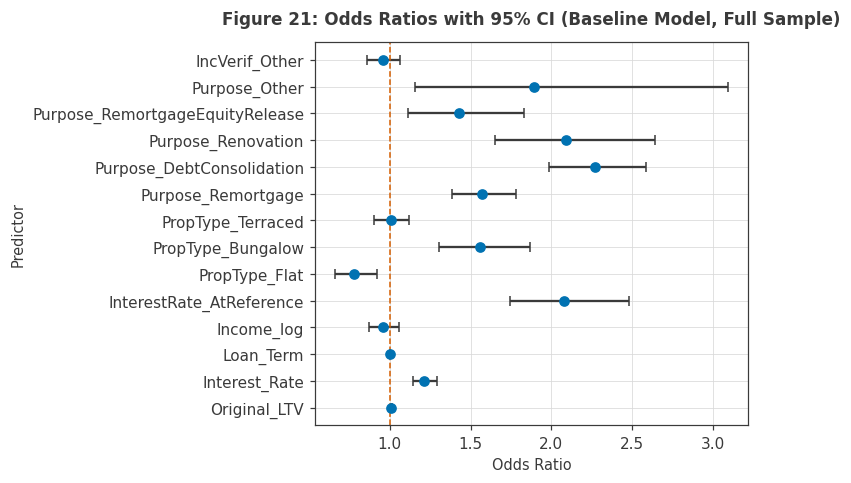

In [18]:
# odds ratios with 95% CI (full-sample baseline model)
or_table = odds_ratios.drop(index="const")
fig, ax = styled_figure("Odds Ratios with 95% CI (Baseline Model, Full Sample)",
                         "Odds Ratio", "Predictor")
y_pos = np.arange(len(or_table))
ax.errorbar(
    or_table["odds_ratio"], y_pos,
    xerr=[or_table["odds_ratio"] - or_table["ci_lower"],
          or_table["ci_upper"] - or_table["odds_ratio"]],
    fmt="o", color=PALETTE["primary"], ecolor=PALETTE["neutral"], capsize=3,
)
ax.axvline(1, color=PALETTE["highlight"], linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(or_table.index)
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig{FIGURE_COUNTER['n']}_odds_ratios.png", bbox_inches="tight")
plt.show()


## Export Result Table

In [19]:
odds_ratios.round(4).to_csv(f"{DATA_FOLDER}/baseline_model_odds_ratios.csv")
print(f"Saved odds ratio table to {DATA_FOLDER}/baseline_model_odds_ratios.csv")


Saved odds ratio table to /content/drive/MyDrive/Dissertation/data/baseline_model_odds_ratios.csv
